Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  67


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  15


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

In [7]:
model = model.add( 
    # 1st block
    nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # 2nd block
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # 3rd block
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # 4th block (NO POOL)
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    # 5th block (NO POOL)
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),

    # Flatten
    nn.Flatten(),

    # 64x64 → 32 → 16 → 8 (final map = 128 × 8 × 8)
    nn.Linear(128 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment2/",
    save_checkpoints=1,
    print_every=10
    )

In [10]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.5813 | Val Loss: 0.7366 | Train Acc: 0.7708 | Val Acc: 0.7235 | Train F1: 0.7713 | Val F1: 0.7258
Epoch [20/100] | Train Loss: 0.4204 | Val Loss: 0.6969 | Train Acc: 0.8559 | Val Acc: 0.7566 | Train F1: 0.8573 | Val F1: 0.7556
Epoch [30/100] | Train Loss: 0.2859 | Val Loss: 0.5986 | Train Acc: 0.9178 | Val Acc: 0.7743 | Train F1: 0.9188 | Val F1: 0.7757
Epoch [40/100] | Train Loss: 0.1956 | Val Loss: 0.5908 | Train Acc: 0.9603 | Val Acc: 0.7832 | Train F1: 0.9607 | Val F1: 0.7849
Epoch [50/100] | Train Loss: 0.1352 | Val Loss: 0.5763 | Train Acc: 0.9797 | Val Acc: 0.7832 | Train F1: 0.9799 | Val F1: 0.7846
Epoch [60/100] | Train Loss: 0.1097 | Val Loss: 0.5831 | Train Acc: 0.9863 | Val Acc: 0.7987 | Train F1: 0.9865 | Val F1: 0.7999
Epoch [70/100] | Train Loss: 0.0716 | Val Loss: 0.6248 | Train Acc: 0.9891 | Val Acc: 0.8009 | Train F1: 0.9893 | Val F1: 0.8022
Epoch [80/100] | Train Loss: 0.0537 | Val Loss: 0.6347 | Train Acc: 0.9957 | Val Acc: 0.8009 | Tr

### Save Metrics

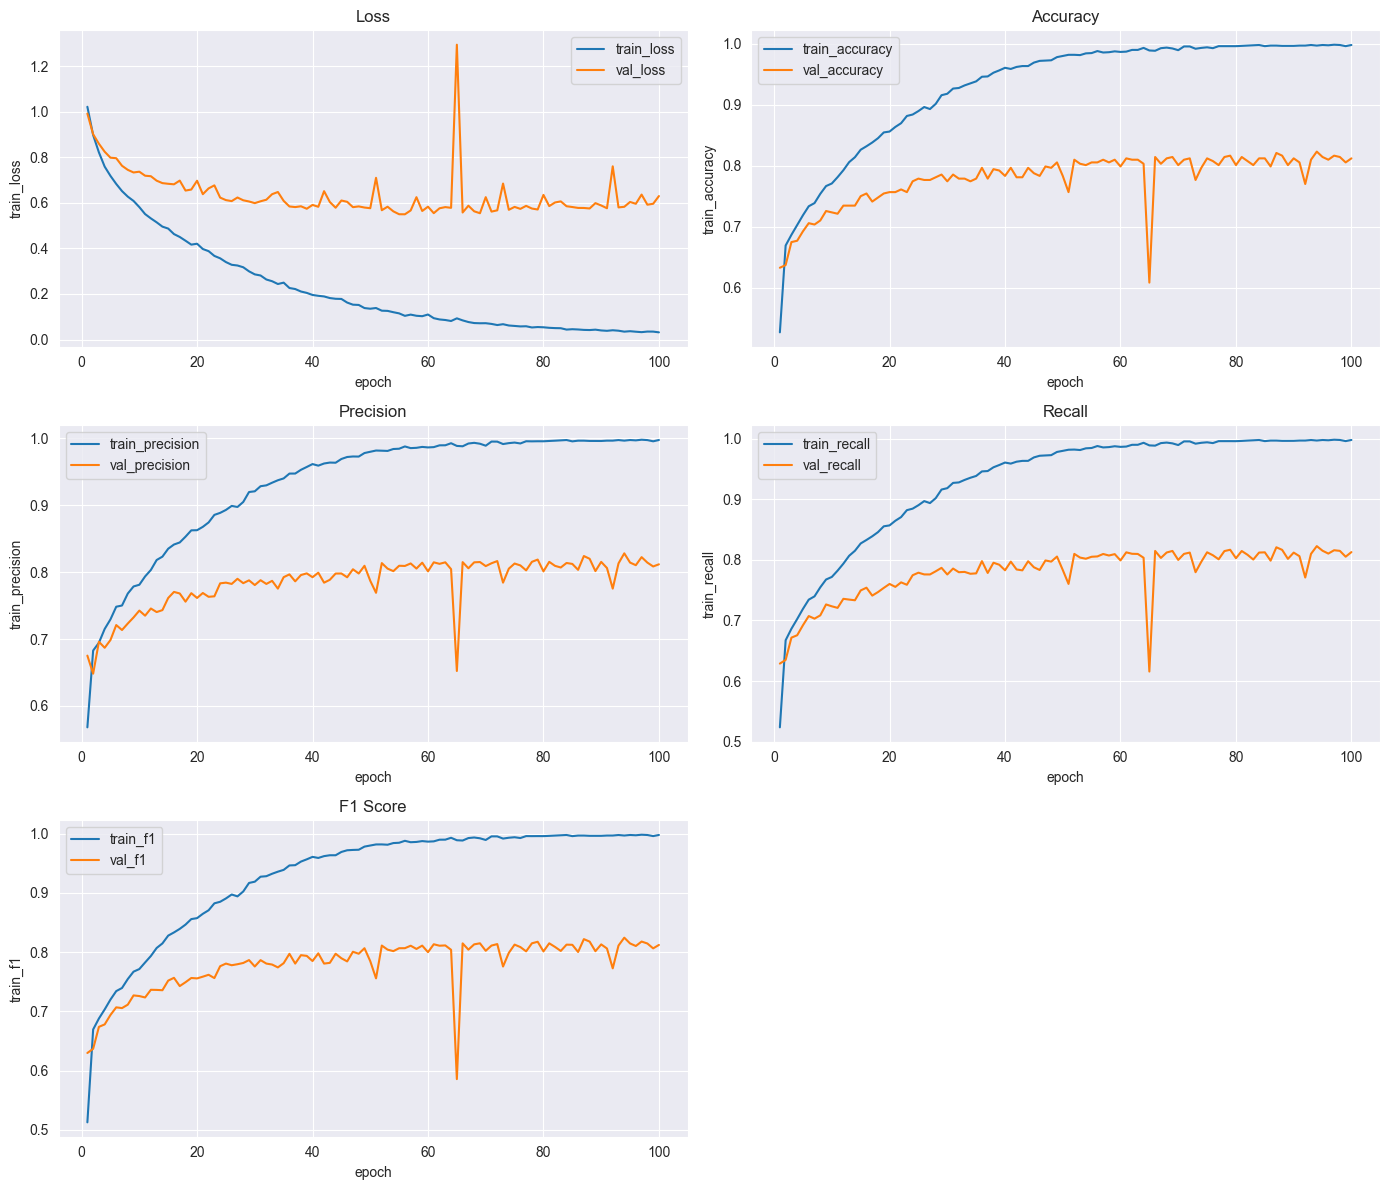

In [11]:
df = plot_training_metrics(history)
df.to_csv("../documentations/resources/experiment2/tables/training_metrics.csv", index=False)

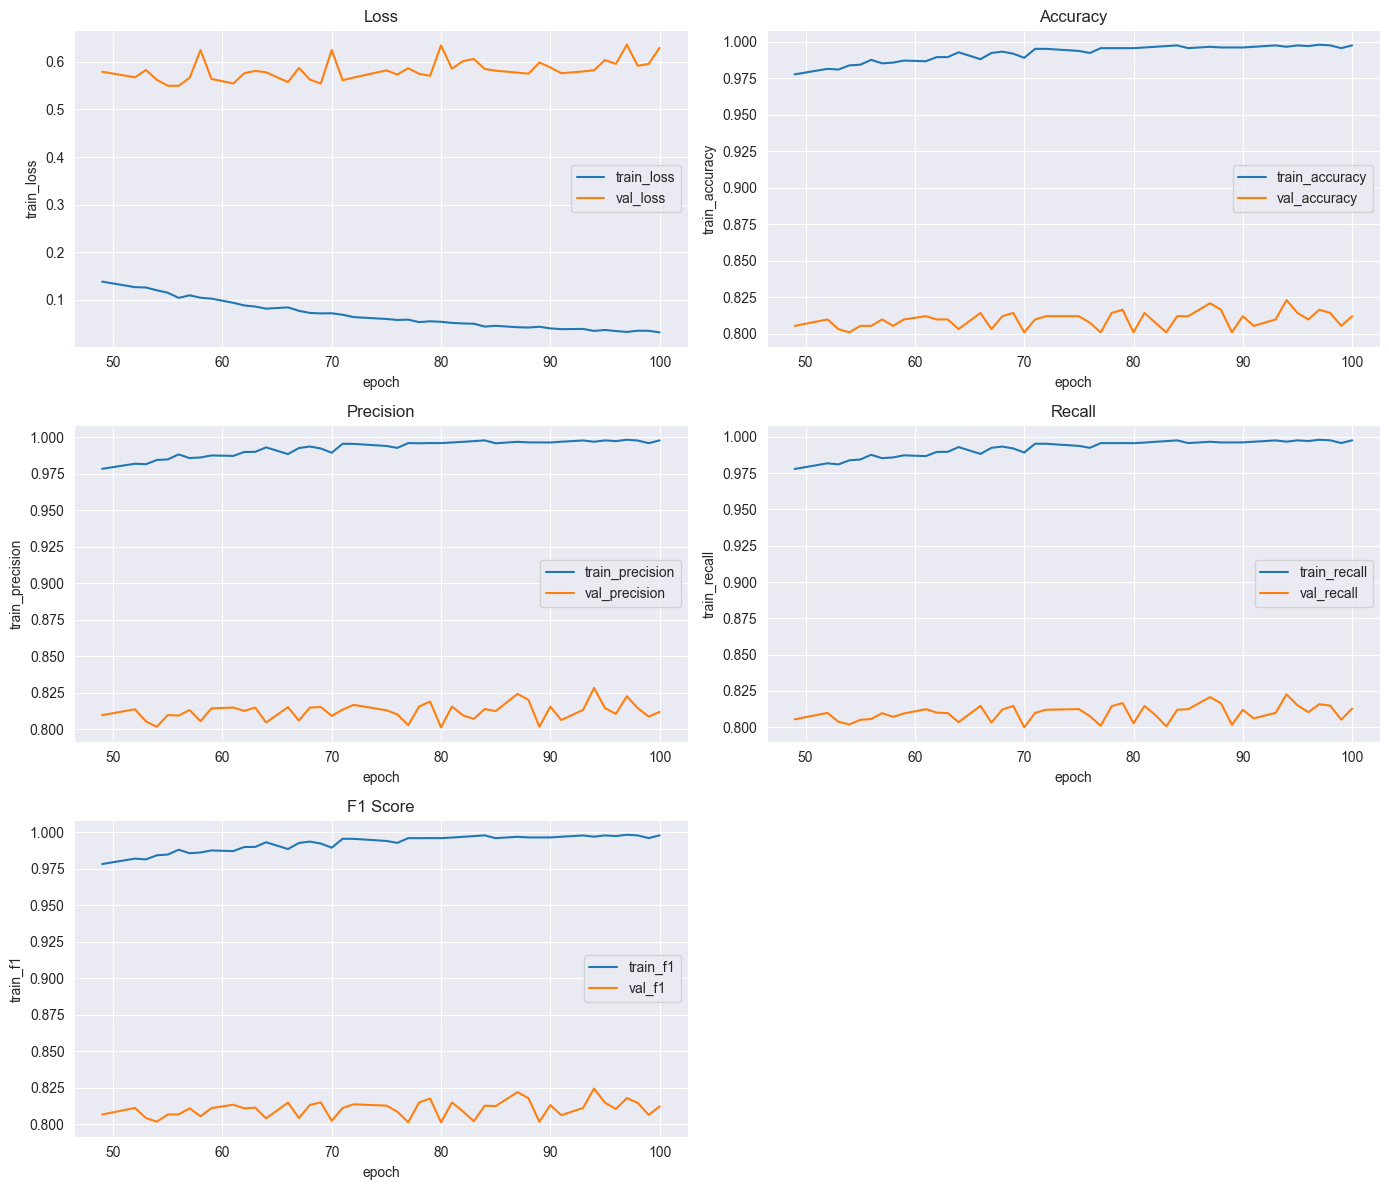

In [12]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

### Training/Validation Trend (100 epochs)

* Early phase (1–15): rapid learning, both train and val improve significantly.
* Mid phase (15–60): steady improvement; validation metrics peak more consistently.
* Late phase (60–100): strong overfitting tendency; training approaches saturation while validation fluctuates in a narrow band.
* Best-performing region for validation F1 is concentrated between epochs 80–97.

The model shows strong learning progress during training, with training loss continuously decreasing from 0.9918 to 0.0121 and training accuracy improving from 52.36% to 100%, indicating that the model successfully learned the training patterns. Validation performance improved steadily in the early epochs, with validation accuracy increasing from 59.29% to a peak of around 82.52%. However, after approximately epoch 27, the training metrics continued improving while validation metrics fluctuated, suggesting the beginning of overfitting. The best generalization performance was achieved around the mid-training stage, where validation accuracy, precision, recall, and F1-score were highest before the model started memorizing the training data.

<b>Best Epoch 87</b>

<b>Loss</b>
* Train Loss = 0.042217305625107754
* Valid Loss = 0.5773782342672348

<b>Training Metrics</b>
* Train Accuracy = 0.996691882610321
* Train Precison = 0.9967427253723145
* Train Recall = 0.9966945648193359
* Train F1 = 0.9967182278633118

<b>Validation Accuracy</b>
* Validation Accuracy = 0.8207964897155762
* Validation Precision = 0.8241321444511414
* Validation Recall = 0.8206400871276855
* Validation F1 = 0.821873664855957

This model has comperatively lower validation metrics. But the training and validation curves are far more smoother. So this model is better overall than previous.


## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment2/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


### Save Test Metrics

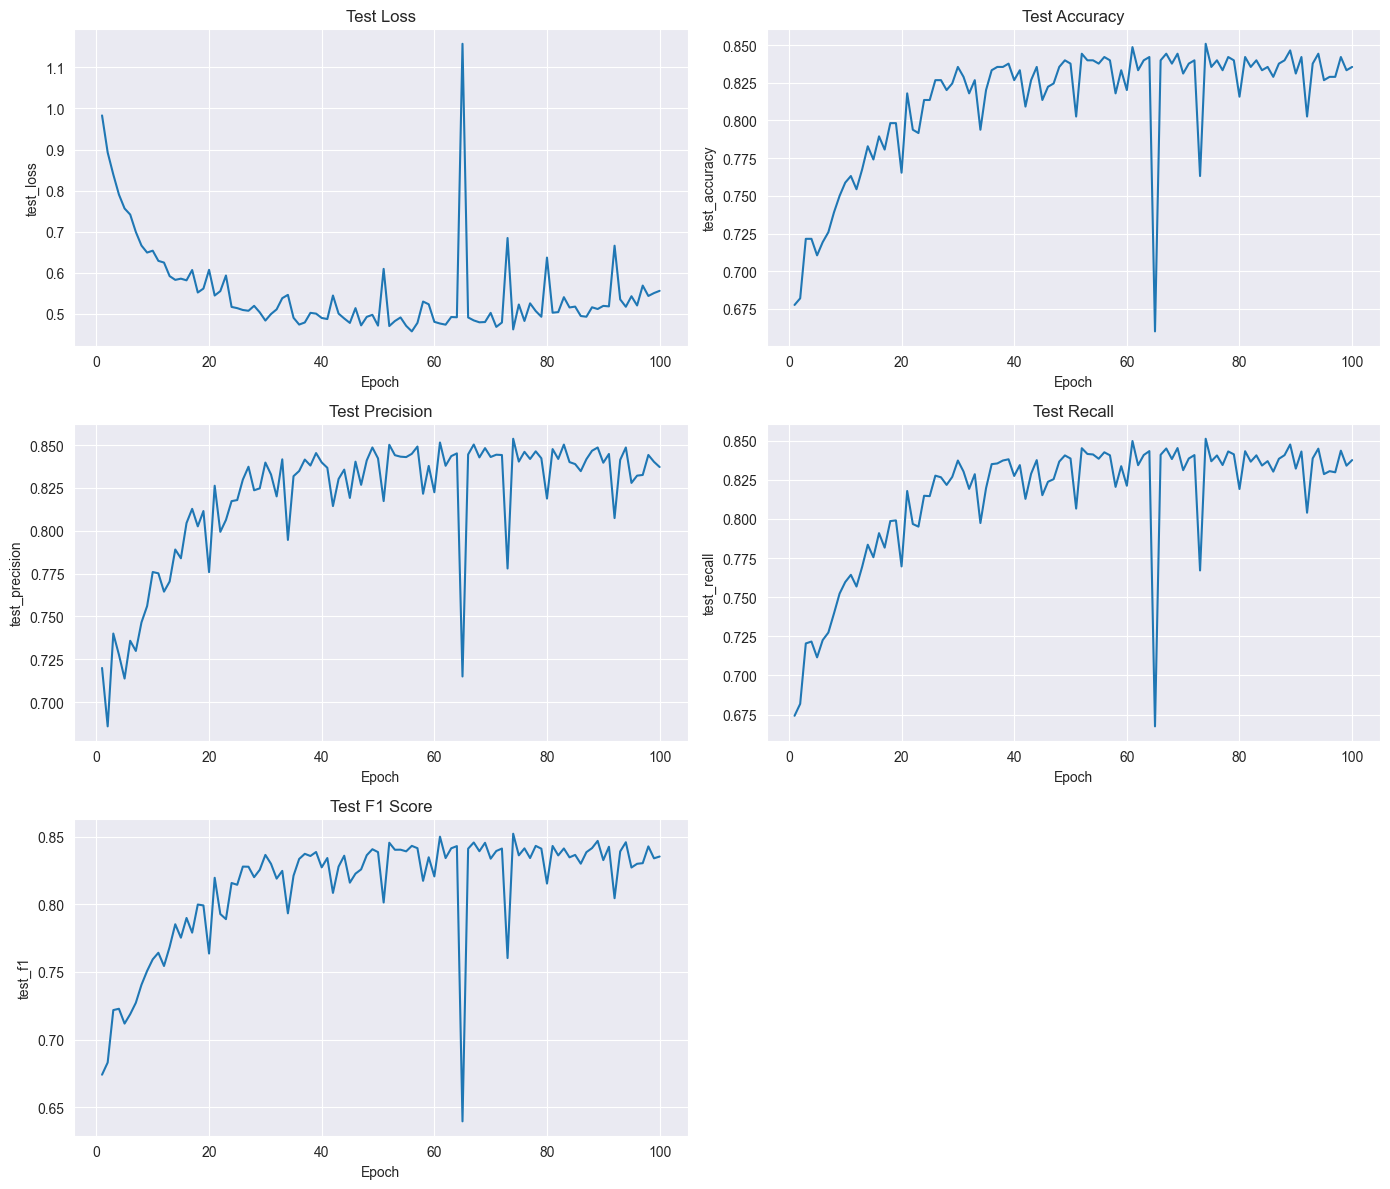

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/resources/experiment2/tables/test_metrics.csv", index=False)

### Test Performance Trend (100 epochs)
* Test loss decreases steadily from epoch 1 to ~epoch 30, then stabilizes in the 0.45–0.55 range with occasional spikes.
* Test accuracy improves rapidly in early epochs (0.67 → ~0.82), then plateaus mostly between ~0.82 and ~0.85.
* Best generalization region is between epochs ~60–95, where metrics are stable and high (~0.83–0.85 accuracy).
* A clear performance jump occurs around epochs 18–30, after which improvements are marginal.
* Several instability points exist (notably epochs 65, 73, 80, 92), where loss spikes and accuracy drops.
* Peak performance is achieved around epoch 89–94 range.

The test performance shows rapid improvement in early epochs followed by a stable convergence phase where performance plateaus around 0.83–0.85 across all key metrics. Minor fluctuations occur in later epochs, but the model maintains consistent generalization without severe overfitting. The optimal trade-off between accuracy, precision, recall, and F1-score is achieved at epoch 89, which provides the highest and most balanced test F1-score while maintaining strong stability across all evaluation metrics.

<b>Best Epoch 89</b>

* Loss = 0.5116161350160837
* Accuracy = 0.8464912176132202
* Precision = 0.8485643267631531
* Recall = 0.8475312590599061
* F1-Score = 0.8467739224433899